# Graph 101: Fundamentals of Graph Representations
---

**Author:** Imad El Maftouhi

This notebook covers the fundamentals of graph representations as a stepping stone toward Graph Neural Networks (GNNs) and more advanced graph-based algorithms. Rather than starting from abstract theory, we build intuition through a concrete examples.

----

In [1]:
# Import necessary libraries
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns
import pandas as pd
import numpy as np
import torch
import time
import cv2

from typing import Optional, Union, List, Tuple, Any
from torch_geometric.utils import to_networkx
from torch_geometric.utils import subgraph
from torch_geometric.data import Data
from collections import defaultdict
from collections import Counter

# What is a Graph ?

## 1.1 Informal Intuition

Before any formal definition, consider these everyday structures:

- A **map** of cities connected by roads
- A **social network** where people follow each other
- A **molecule** where atoms are bonded together
- A **web page** linking to other web pages

All of these share a common pattern: **entities** and **relationships between them**. A graph is simply the mathematical abstraction of that pattern.

## 1.2 Formal Definition

A graph **G** is defined as a pair:

$$G = (V, E)$$

Where:
- **V** is a finite set of **vertices** (also called **nodes**) — the entities
- **E** is a set of **edges** — the relationships between entities

Each edge $e \in E$ connects a pair of nodes $(u, v)$ where $u, v \in V$.

**Example:**

Consider 4 cities connected by direct train routes:

```
V = {Paris, Lyon, Marseille, Bordeaux}
E = {(Paris, Lyon), (Lyon, Marseille), (Paris, Bordeaux)}
```

This gives a graph with **4 nodes** and **3 edges**.

## 1.3 Directed vs Undirected Graphs

The nature of the relationship between two nodes determines whether a graph is **directed** or **undirected**.

### Undirected Graph
An edge $(u, v)$ has **no direction** — the relationship is symmetric. If $u$ is connected to $v$, then $v$ is connected to $u$.

$$E \subseteq \big\{\{u, v\} \mid u, v \in V,\ u \neq v\big\}$$

**Examples:** friendship on Facebook, road between two cities, pixel neighborhood in an image.

```
A ── B
|   |
C ── D
```

### Directed Graph (Digraph)
An edge $(u, v)$ has a **direction** — it goes *from* $u$ *to* $v$. The reverse edge $(v, u)$ is a different edge and may or may not exist.

$$E \subseteq \big\{(u, v) \mid u, v \in V,\ u \neq v\big\}$$

**Examples:** following on Twitter, hyperlinks between web pages, citation networks.

```
A ──► B
▲     |
|     ▼
C ◄── D
```

> **Key distinction:** In an undirected graph, edges are *sets* $\{u, v\}$ — order doesn't matter. In a directed graph, edges are *ordered pairs* $(u, v)$ — order matters.

## 1.4 Weighted vs Unweighted Graphs

So far, edges only encode *whether* a connection exists. Often we also want to encode *how strong* or *how costly* a connection is — this is done with **weights**.

### Unweighted Graph
Every edge is equally significant. The edge either exists or it doesn't.

### Weighted Graph
Each edge $e = (u, v)$ carries a scalar weight $w(u, v) \in \mathbb{R}$:

$$G = (V, E, w) \quad \text{where} \quad w: E \to \mathbb{R}$$

**Examples:**
| Graph | Weight meaning |
|---|---|
| Road network | Distance in km |
| Molecule | Bond strength |
| Pixel graph | Color dissimilarity between adjacent pixels |
| Social network | Interaction frequency |

Weights can represent **cost**, **capacity**, **similarity**, **distance**, or any numeric relationship between nodes.

## 1.5 Node and Edge Features

In machine learning we go beyond topology and attach **feature vectors** to nodes and edges:

- **Node features** $\mathbf{x}_v \in \mathbb{R}^d$ — properties of the entity itself
- **Edge features** $\mathbf{e}_{uv} \in \mathbb{R}^k$ — properties of the relationship

| Domain | Node features | Edge features |
|---|---|---|
| Social network | Age, location, interests | Friendship duration |
| Molecule | Atom type, charge | Bond type, bond length |
| Image | RGB pixel values | Color distance between neighbors |
| Road network | City population | Road length, speed limit |


> In PyTorch Geometric, node features are stored as `x` of shape `[num_nodes, num_features]`, and edge features as `edge_attr` of shape `[num_edges, num_edge_features]`.

## 1.6 Simple Graphs vs Multigraphs

A **simple graph** allows at most one edge between any pair of nodes and no self-loops (an edge from a node to itself).

A **multigraph** relaxes these constraints:

| Variant | What it allows |
|---|---|
| Multigraph | Multiple edges between the same pair of nodes |
| Graph with self-loops | A node can have an edge pointing to itself |

**When do these arise?**
- A person can send multiple messages to another → multigraph
- A neuron with a recurrent connection → self-loop
- A knowledge graph with multiple relation types between the same entities → multigraph

Most GNN frameworks assume simple graphs by default, but PyG supports both multigraphs and self-loops.

## 1.7 Adjacency — Who is Connected to Whom?

The **adjacency** of a node $v$ is the set of nodes it is directly connected to, also called its **neighbors**:

$$\mathcal{N}(v) = \{u \in V \mid (v, u) \in E\}$$

The **degree** of a node is the number of its neighbors:

$$\deg(v) = |\mathcal{N}(v)|$$

In a directed graph we distinguish:
- **In-degree**: number of edges *arriving at* $v$
- **Out-degree**: number of edges *leaving* $v$

## 1.8 Summary

| Property | Options |
|---|---|
| Edge direction | Directed / Undirected |
| Edge weights | Weighted / Unweighted |
| Node features | Present / Absent |
| Edge features | Present / Absent |
| Self-loops | Allowed / Forbidden |
| Multi-edges | Allowed / Forbidden |

A typical graph used in a GNN is **directed or undirected**, **weighted**, with **node and edge features**, and is assumed to be a **simple graph** unless stated otherwise.

## 1.9 Real-World Examples

| Domain | Nodes | Edges | Node features | Edge features |
|---|---|---|---|---|
| Social network | Users | Follows / Friends | Profile info | Interaction frequency |
| Citation network | Papers | Paper A cites B | Abstract embeddings | — |
| Molecule | Atoms | Chemical bonds | Atom type, charge | Bond type |
| Knowledge graph | Entities | Relations (*is-a*, *part-of*) | Entity embeddings | Relation type |
| Image | Pixels | Spatial adjacency (8-connectivity) | RGB values | Color dissimilarity |
| Road network | Intersections | Road segments | Coordinates | Length, speed limit |
| Brain connectivity | Brain regions | Neural connections | Activation levels | Connection strength |

---

> **Coming up next →** Section 2 covers how graphs are *represented in memory* — adjacency matrices, adjacency lists, and the COO edge list format used by PyTorch Geometric.

---


# 2. Graph Representations 

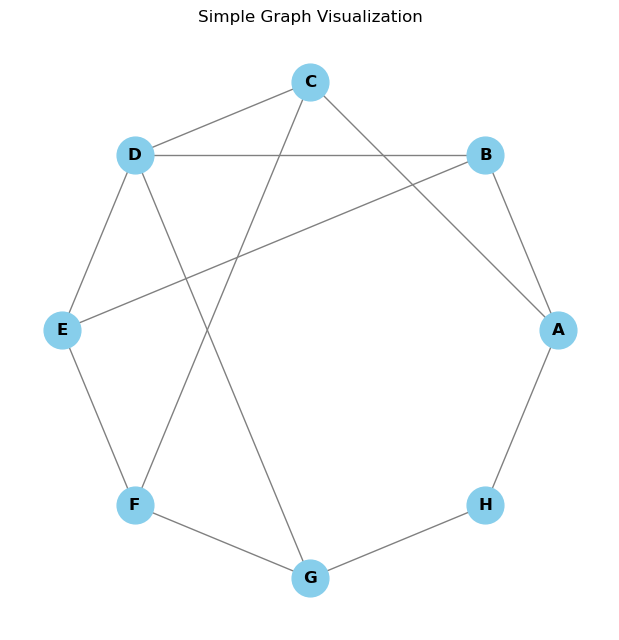

In [2]:
# let's consider a simple graph and then we will see the code for different representations
nodes = ["A", "B", "C", "D", "E", "F", "G", "H"]
edges = [(0, 1),(0, 2),(1, 3),(2, 3),(3, 4),(4, 5),(5, 6),(6, 7),(7, 0),(1, 4),(2, 5),(3, 6)]

# to visualize the graph, we can use the networkx library
G = nx.Graph()
G.add_nodes_from(nodes)
G.add_edges_from([(nodes[u], nodes[v]) for u, v in edges])

pos = nx.circular_layout(G)

plt.figure(figsize=(6, 6))
nx.draw(G,pos,with_labels=True,node_color='skyblue',edge_color='gray',node_size=700,font_weight='bold')
plt.title("Simple Graph Visualization")
plt.axis('off')
plt.show()

In [3]:
letter = "A"
print(int(letter, 36)-9)

1


## Adjacency Matrices

In [4]:
"""
An adjacency matrice is a 2D square array where the rows and columns represent the nodes of the graph. The value at the intersection of a row and column indicates whether there is an edge between the corresponding nodes. For example, if there is an edge from node A to node B, then the value at the intersection of row A and column B would be 1 (or True), while if there is no edge, it would be 0 (or False). We can also use weights instead of binary values to represent the strength or cost of the connection between nodes.
If the graph is undirected, the adjacency matrice will be symmetric, meaning that the value at the intersection of row A and column B will be the same as the value at the intersection of row B and column A. If the graph is directed, the adjacency matrice may not be symmetric, as there may be an edge from node A to node B but not from node B to node A. 
"""    

adjacency_matrice = np.zeros((len(nodes), len(nodes)), dtype=int)
for node in nodes:
    node_idx = nodes.index(node)
    for edge in edges:
        if node_idx in edge:
            other_idx = edge[1] if edge[0] == node_idx else edge[0]
            adjacency_matrice[node_idx, other_idx] = 1
print("Adjacency Matrice:\n", adjacency_matrice) 


Adjacency Matrice:
 [[0 1 1 0 0 0 0 1]
 [1 0 0 1 1 0 0 0]
 [1 0 0 1 0 1 0 0]
 [0 1 1 0 1 0 1 0]
 [0 1 0 1 0 1 0 0]
 [0 0 1 0 1 0 1 0]
 [0 0 0 1 0 1 0 1]
 [1 0 0 0 0 0 1 0]]


## Adjacency list

In [5]:
# adjacency list is a collection of lists or dictionaries where each key represents a node and the corresponding value is a list of neighboring nodes. For example, if node A is connected to nodes B and C, then the adjacency list would have an entry like A: [B, C]. This representation is more space-efficient for sparse graphs, as it only stores the existing edges rather than all possible connections.
adjacency_list = defaultdict(list)
for edge in edges:
    adjacency_list[edge[0]].append(edge[1])
    adjacency_list[edge[1]].append(edge[0])  # For undirected graph

print("Adjacency List:", dict(adjacency_list))

Adjacency List: {0: [1, 2, 7], 1: [0, 3, 4], 2: [0, 3, 5], 3: [1, 2, 4, 6], 4: [3, 5, 1], 5: [4, 6, 2], 6: [5, 7, 3], 7: [6, 0]}


## COO Edge list format

In [6]:
"""
- Edge list is a simple representation of a graph where each edge is represented as a pair of nodes. For example, if there is an edge between node A and node B, it can be represented as (A, B). This representation is straightforward and easy to understand, but it may not be the most efficient for certain graph algorithms, especially when dealing with large graphs. It can also be less efficient in terms of space complexity compared to adjacency lists or matrices, as it may require more storage for large graphs with many edges.

- COO format is a sparse matrix format that represents a graph using three arrays: row, column, and data. The row array contains the row indices of the non-zero entries, the column array contains the column indices of the non-zero entries, and the data array contains the values of the non-zero entries. In the context of a graph, the row and column arrays represent the source and target nodes of the edges, respectively, while the data array can represent edge weights or simply indicate the presence of an edge (e.g., with a value of 1). This format is particularly efficient for storing and processing sparse graphs, as it only stores information about existing edges rather than all possible connections.

"""

edge_list = np.array(edges).T
print(f"Edge list in COO format : \n{edge_list}")

Edge list in COO format : 
[[0 0 1 2 3 4 5 6 7 1 2 3]
 [1 2 3 3 4 5 6 7 0 4 5 6]]


## Trade-offs: memory, lookup speed, sparsity

Assuming a graph with n nodes and m edges

1. Adjacency Matrix
- Space: O(n^2) - stores all possible pairs, even if no edge exists
- Check edge existence: O(1) - direct array access
- Iterate neighbors: O(n) - scan entire row
- Suitable for dense graphs

2. Adjacency List
- Space: O(n + m) - only stores existing edges
- Check edge existence: O(degree(u)) - scan list of neighbors
- Iterate neighbors: O(degree(u)) - direct list traversal
- Suitable for sparse graphs

3. Edge List / COO Format
- Space: O(m) - only stores edges
- Check edge existence: O(m) - scan entire list
- Iterate neighbors: O(m) - requires building adjacency from edges first
- Suitable for very sparse graphs or when edges are the focus

In [7]:
# Example with the current graph (n=8, m=12)
n = len(nodes)
m = len(edges)

print(f"Graph: {n} nodes, {m} edges")
print(f"Adjacency Matrix space: {n*n} entries (dense)")
print(f"Adjacency List space: {sum(len(adjacency_list[i]) for i in adjacency_list)} entries (sparse)")
print(f"Edge List space: {m} entries")

# Time examples (simplified, not actual timing)

# Check edge (0,1) exists
start = time.time()
exists_matrix = adjacency_matrice[0,1] == 1
print(f"Matrix check: {time.time()-start:.6f}s, result: {exists_matrix}")

start = time.time()
exists_list = 1 in adjacency_list[0]
print(f"List check: {time.time()-start:.6f}s, result: {exists_list}")

start = time.time()
exists_edge = (0,1) in edges
print(f"Edge list check: {time.time()-start:.6f}s, result: {exists_edge}")

# Iterate neighbors of node 0
print("Neighbors of 0 (matrix):", [i for i in range(n) if adjacency_matrice[0,i] == 1])
print("Neighbors of 0 (list):", adjacency_list[0])
print("Neighbors of 0 (edge list):", [e[1] for e in edges if e[0]==0] + [e[0] for e in edges if e[1]==0])

Graph: 8 nodes, 12 edges
Adjacency Matrix space: 64 entries (dense)
Adjacency List space: 24 entries (sparse)
Edge List space: 12 entries
Matrix check: 0.000000s, result: True
List check: 0.000000s, result: True
Edge list check: 0.000000s, result: True
Neighbors of 0 (matrix): [1, 2, 7]
Neighbors of 0 (list): [1, 2, 7]
Neighbors of 0 (edge list): [1, 2, 7]


## Examples

Weighted Adjacency Matrix:
 [[0.   0.5  1.   0.   0.   0.   0.   0.4 ]
 [0.5  0.   0.   0.75 0.7  0.   0.   0.  ]
 [1.   0.   0.   0.25 0.   0.2  0.   0.  ]
 [0.   0.75 0.25 0.   0.9  0.   0.85 0.  ]
 [0.   0.7  0.   0.9  0.   0.6  0.   0.  ]
 [0.   0.   0.2  0.   0.6  0.   0.8  0.  ]
 [0.   0.   0.   0.85 0.   0.8  0.   0.3 ]
 [0.4  0.   0.   0.   0.   0.   0.3  0.  ]]


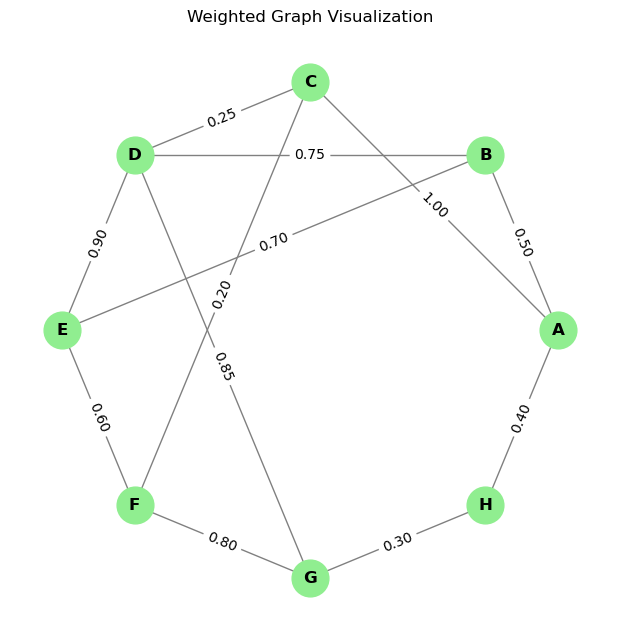

In [8]:
## Example 2 - Weighted Graph
nodes = ["A", "B", "C", "D", "E", "F", "G", "H"]
edges_weighted = [(0, 1, 0.5),(0, 2, 1.0),(1, 3, 0.75),(2, 3, 0.25),(3, 4, 0.9),(4, 5, 0.6),(5, 6, 0.8),(6, 7, 0.3),(7, 0, 0.4),(1, 4, 0.7),(2, 5, 0.2),(3, 6, 0.85)]

adjacency_matrix_weighted = np.zeros((len(nodes), len(nodes)), dtype=float)
for edge in edges_weighted:
    adjacency_matrix_weighted[edge[0], edge[1]] = edge[2]
    adjacency_matrix_weighted[edge[1], edge[0]] = edge[2]  # For undirected graph

print("Weighted Adjacency Matrix:\n",adjacency_matrix_weighted)

G = nx.Graph()
G.add_nodes_from(nodes)
G.add_weighted_edges_from([(nodes[u], nodes[v], w) for u, v, w in edges_weighted])
pos = nx.circular_layout(G)
plt.figure(figsize=(6,6))
nx.draw(G, pos, with_labels=True, node_color='lightgreen', edge_color='gray', node_size=700, font_weight='bold')
edge_labels = {(nodes[u], nodes[v]): f"{w:.2f}" for u, v, w in edges_weighted}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.title("Weighted Graph Visualization")
plt.axis('off')
plt.show()


Directed Adjacency Matrix:
 [[0 1 1 0 0 0 0 0]
 [0 0 0 1 1 0 0 0]
 [0 0 0 1 0 1 0 0]
 [0 0 0 0 1 0 1 0]
 [0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 0]]


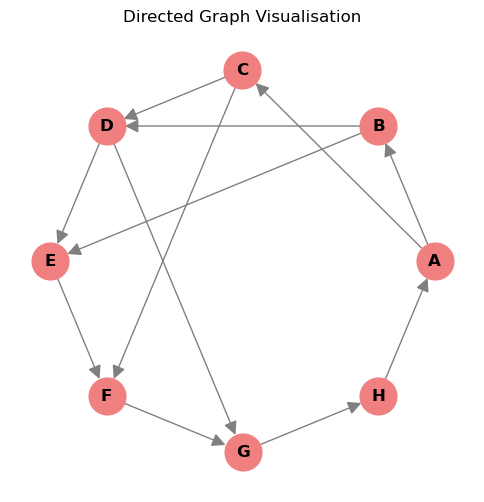

In [9]:
## Example 3 - Directed graph
nodes = ["A", "B", "C", "D", "E", "F", "G", "H"]
edges_directed = [(0, 1),(0, 2),(1, 3),(2, 3),(3, 4),(4, 5),(5, 6),(6, 7),(7, 0),(1, 4),(2, 5),(3, 6)]
adjacency_matrix_directed = np.zeros((len(nodes), len(nodes)), dtype=int)
for edge in edges_directed:
    adjacency_matrix_directed[edge[0], edge[1]] = 1
print("Directed Adjacency Matrix:\n", adjacency_matrix_directed)

G = nx.DiGraph()
G.add_nodes_from(nodes)
G.add_edges_from([(nodes[u], nodes[v]) for u, v in edges_directed])
pos = nx.circular_layout(G)
plt.figure(figsize=(6,6))
plt.axis("off")
nx.draw(G, pos, with_labels=True, node_color="lightcoral", edge_color='gray', node_size=700, font_weight='bold', arrowsize=20)
plt.title("Directed Graph Visualisation")
plt.show()

Bipartite Adjacency Matrix:
 [[0 0 0 0 1 1 0 0]
 [0 0 0 0 0 1 1 0]
 [0 0 0 0 0 0 1 1]
 [0 0 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 0]
 [1 1 0 0 0 0 0 0]
 [0 1 1 0 0 0 0 0]
 [0 0 1 1 0 0 0 0]]


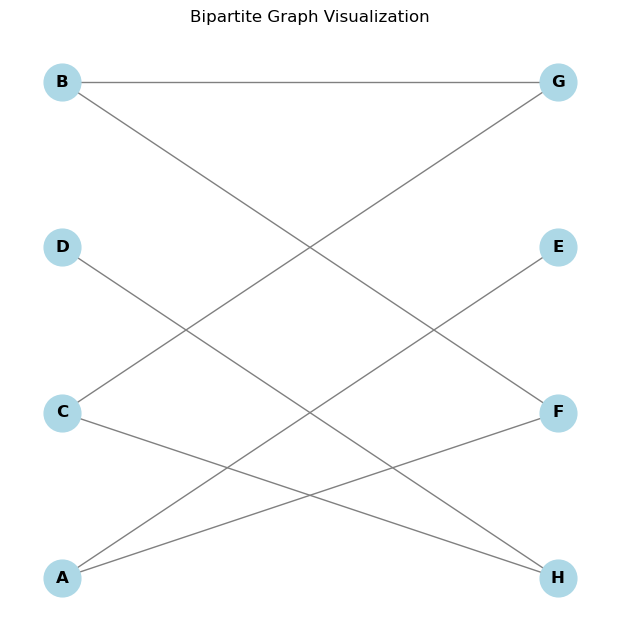

In [10]:
## example 4 - Bipartite graph
nodes_top = ["A", "B", "C", "D"]
nodes_bottom = ["E", "F", "G", "H"]
edges_bipartite = [(0, 4),(0, 5),(1, 5),(1, 6),(2, 6),(2, 7),(3, 7)]
adjacency_matrix_bipartite = np.zeros((len(nodes_top)+len(nodes_bottom), len(nodes_top)+len(nodes_bottom)), dtype=int)
for edge in edges_bipartite:
    adjacency_matrix_bipartite[edge[0], edge[1]] = 1
    adjacency_matrix_bipartite[edge[1], edge[0]] = 1  # For undirected graph
print("Bipartite Adjacency Matrix:\n", adjacency_matrix_bipartite)

G = nx.Graph()
G.add_nodes_from(nodes_top, bipartite=0)
G.add_nodes_from(nodes_bottom, bipartite=1)
G.add_edges_from([(nodes_top[u], nodes_bottom[v-4]) for u, v in edges_bipartite])
pos = nx.bipartite_layout(G, nodes_top)
plt.figure(figsize=(6,6))
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=700, font_weight='bold')
plt.title("Bipartite Graph Visualization")  
plt.axis('off')
plt.show()

Weighted Directed Adjacency Matrix:
 [[0.3  0.5  1.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.75 0.7  0.   0.   0.  ]
 [0.   0.   0.   0.25 0.   0.2  0.   0.  ]
 [0.   0.   0.   0.   0.9  0.   0.85 0.  ]
 [0.   0.   0.   0.   0.   0.6  0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.8  0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.3 ]
 [0.4  0.   0.   0.   0.   0.   0.   0.  ]]


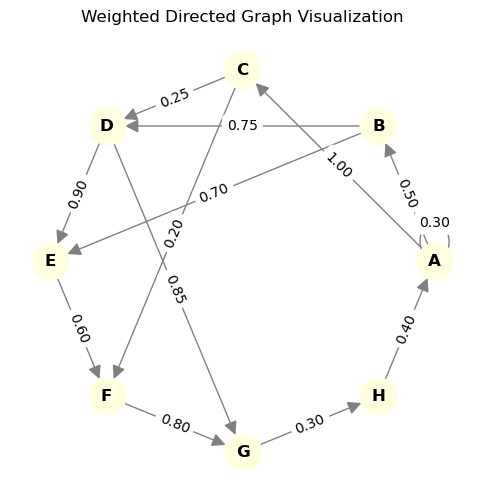

In [11]:
# Example 5 : weighted directed graph


nodes = ["A", "B", "C", "D", "E", "F", "G", "H"]
edges_weighted_directed = [(0, 0, 0.3), (0, 1, 0.5),(0, 2, 1.0),(1, 3, 0.75),(2, 3, 0.25),(3, 4, 0.9),(4, 5, 0.6),(5, 6, 0.8),(6, 7, 0.3),(7, 0, 0.4),(1, 4, 0.7),(2, 5, 0.2),(3, 6, 0.85)]
adjacency_matrix_weighted_directed = np.zeros((len(nodes), len(nodes)), dtype=float)
for edge in edges_weighted_directed:
    adjacency_matrix_weighted_directed[edge[0], edge[1]] = edge[2]
print("Weighted Directed Adjacency Matrix:\n", adjacency_matrix_weighted_directed)

G = nx.DiGraph()
G.add_nodes_from(nodes)
G.add_weighted_edges_from([(nodes[u], nodes[v], w) for u, v, w in edges_weighted_directed])
pos = nx.circular_layout(G)
plt.figure(figsize=(6,6))
plt.axis("off")
nx.draw(G, pos, with_labels=True, node_color="lightyellow", edge_color='gray', node_size=700, font_weight='bold', arrowsize=20)
edge_labels = {(nodes[u], nodes[v]): f"{w:.2f}" for u, v, w in edges_weighted_directed}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.title("Weighted Directed Graph Visualization")
plt.show()



# Node and Edge Features

The binary structure by which a graph is defined, alone carries no semantics. Features are the mechanism by which we attach real-valued or categorical measurements to these discrete elements. Without features, a graph is a skeleon with features, it becomes a representations of a system. 

Node features represent properties intrinsic to each entity in the domain being modeled. In a social network, a node feature might be the age of a user, their nummber of past posts, or a learned embedding of their interests. In a moleculen, node features are atomic numbers, partial charges or a hybridization states. The key property of a node feature is that it is attached to the node irrespectiev of its neighbords. If you permute the graph's adjacency matrix and apply the same permutation to the node feature matrix, the semantics of the data do not changes. This invariance under isomorphism* is the defining characteristic. 
    
>*Two simple graphs G1 = (V1,E1) and G2 = (V2,E2) are isomorphic if there is a bijection f : V1 → V2 such that (a, b) ∈ E1 ⇐⇒ (f(a),f(b)) ∈ E2. A graph invariant is a property of a graph that is preserved by isomorphisms.

Edge features represent properties of the relationship or interaction between two nodes. In a transportation network, an edge feature might be distance, travel time, or road capacity. In a knowledge graph, edge features encode relation types such as 'is a prent of' or 'located in'. Unlike node features, edge features are not permutation-invariant in isolation; they transform with the node ordering in a bilinear or coupled manner. More importantly, edge features often break the symmetry of the graph. Two nodes with identical feature vectors can be distinguished by the features on their incident edges. This is why graph neural networks that ignore edge features lose significant expressive power. 

A subtle but critical point is that node and edge features are not independent. In many natural graph, edge features are functions of the node features a their endpoints. For example, the weight of an edge in a Euclidean graph is the distance between node coordinates. In such cases, the edge features are redundant given the node features.But in general, edge features introduce new information, A citation network might have node features representing paper abstracts and edge features representing citation sentiment of section reference. there is no function from the abstract of a paper alone to the sentiment of a citataion it receives from another paper. 


## Example: Node Features

Data(x=[5, 4], edge_index=[2, 7])

Node features shape: torch.Size([5, 4])
Node features:
tensor([[ 1,  2,  3,  4],
        [ 5,  6,  7,  8],
        [ 9, 10, 11, 12],
        [13, 14, 15, 16],
        [17, 18, 19, 20]])

Edge index shape: torch.Size([2, 7])
Edge index:
tensor([[0, 0, 1, 1, 2, 3, 4],
        [1, 2, 2, 3, 4, 4, 0]])


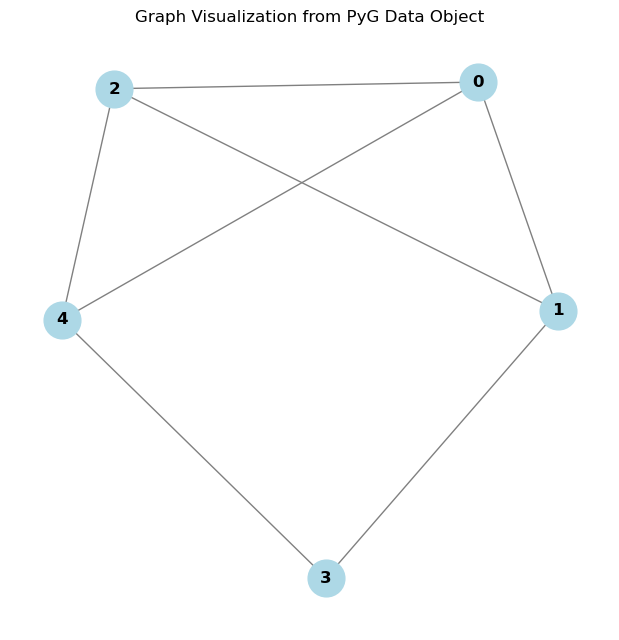

In [12]:
# Create a small graph with 5 nodes, each with 4 integer features
num_nodes = 5
num_features = 4

# Node features: 5 nodes × 4 features
x = torch.tensor([
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 10, 11, 12],
    [13, 14, 15, 16],
    [17, 18, 19, 20]
], dtype=torch.long)

# Edge index: define connections between nodes
edge_index = torch.tensor([
    [0, 0, 1, 1, 2, 3, 4],  # source nodes
    [1, 2, 2, 3, 4, 4, 0]   # target nodes
], dtype=torch.long)

data = Data(x=x, edge_index=edge_index)
print(data)
print(f"\nNode features shape: {data.x.shape}")
print(f"Node features:\n{data.x}")
print(f"\nEdge index shape: {data.edge_index.shape}")
print(f"Edge index:\n{data.edge_index}")

# visualising
G = to_networkx(data, to_undirected=True)
pos = nx.spring_layout(G)
plt.figure(figsize=(6,6))
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=700, font_weight='bold')
plt.title("Graph Visualization from PyG Data Object")
plt.axis('off')
plt.show()

In [13]:
# one key thing to note from this visualisation is how we're missing the features tensor visualisation. 
# we have three option to overcome this limitation.

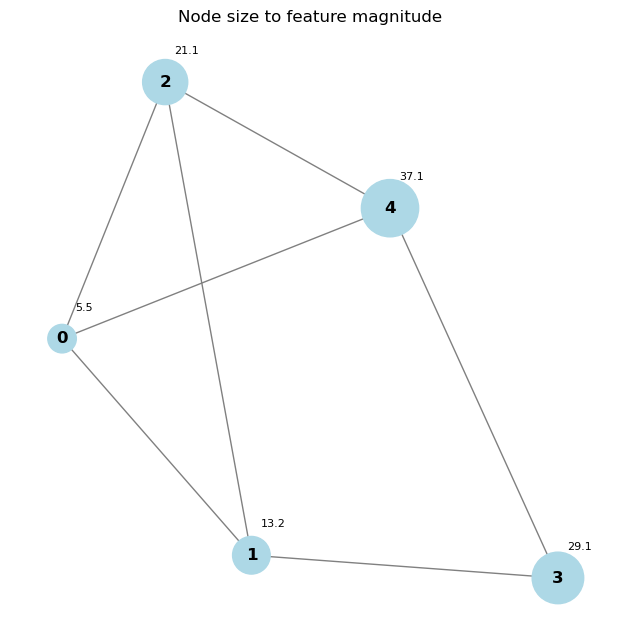

In [14]:
# Option 1 : Feature magnitude -> node size
G = to_networkx(data, to_undirected=True)
pos = nx.spring_layout(G)
magnitudes = data.x.float().norm(dim=1).numpy()
node_sizes = 200 + (magnitudes / magnitudes.max()) * 1500  # scale to [200, 1700]

plt.figure(figsize=(6, 6))
nx.draw(G, pos, with_labels=True, node_color='lightblue',
        node_size=node_sizes, edge_color='gray', font_weight='bold')

mag_labels = {i: f"{magnitudes[i]:.1f}" for i in range(len(magnitudes))}
offset_pos = {node: (x + 0.08, y + 0.08) for node, (x, y) in pos.items()}
nx.draw_networkx_labels(G, offset_pos, labels=mag_labels, font_size=8, font_color='black')

plt.title("Node size to feature magnitude")
plt.show()


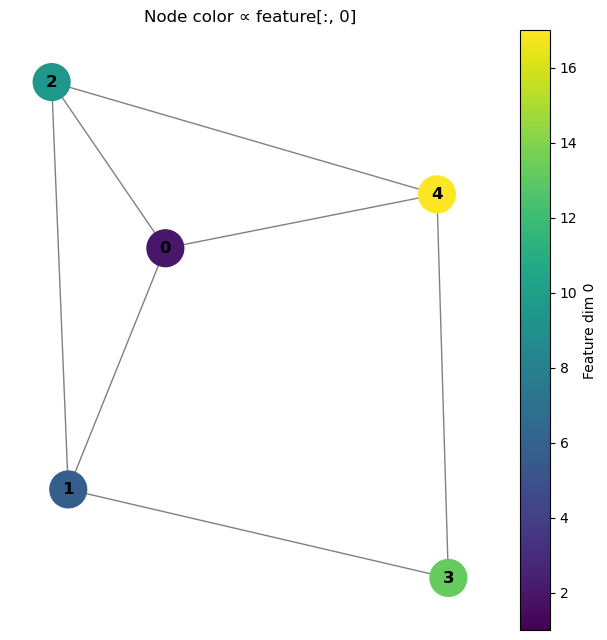

In [15]:
G = to_networkx(data, to_undirected=True)
pos = nx.spring_layout(G)

feature_vals = data.x[:, 0].numpy()  # use first feature dimension
node_colors = plt.cm.viridis(feature_vals / feature_vals.max())

plt.figure(figsize=(6, 6))
nx.draw(G, pos, with_labels=True, node_color=node_colors,
        node_size=700, edge_color='gray', font_weight='bold')
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(feature_vals.min(), feature_vals.max()))
plt.colorbar(sm, label='Feature dim 0', ax=plt.gca())
plt.title("Node color ∝ feature[:, 0]")
plt.show()


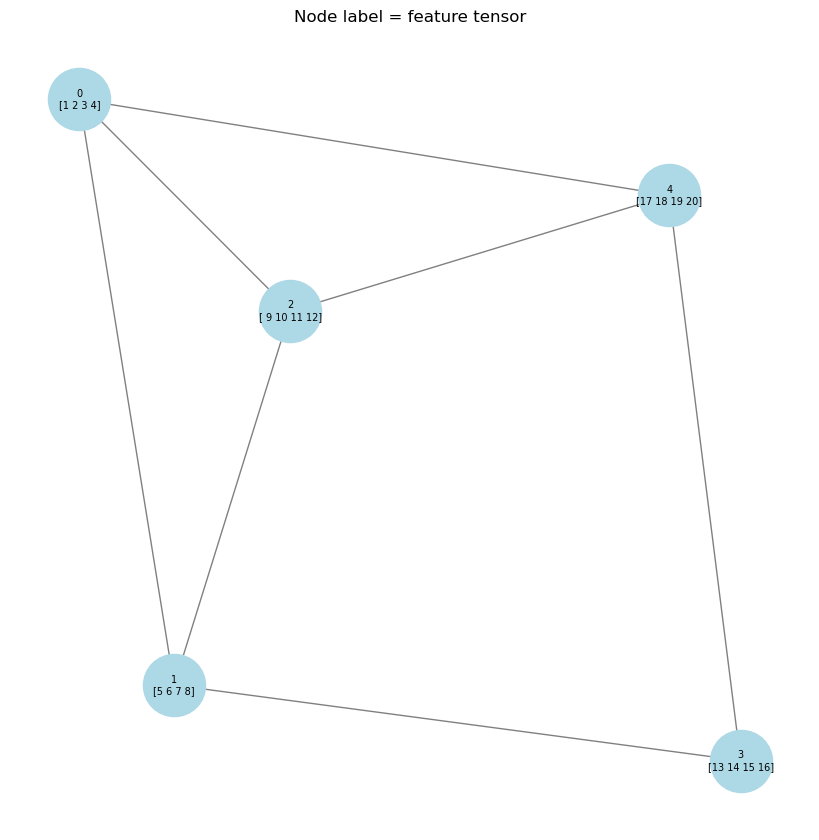

In [16]:
# option 3 : Show raw tensor as label (works well for small graphs)

G = to_networkx(data, to_undirected=True)
pos = nx.spring_layout(G)

labels = {
    i: f"{i}\n{data.x[i].numpy().round(2)}"
    for i in range(data.num_nodes)
}

plt.figure(figsize=(8, 8))
nx.draw(G, pos, labels=labels, node_color='lightblue',
        node_size=2000, edge_color='gray', font_size=7)
plt.title("Node label = feature tensor")
plt.show()


## Example : Edge features 

Edge feature tensor shape: torch.Size([14, 4])

=== Edge Feature Tensor Analysis ===
Min value : 0.100
Max value : 5.600
Mean      : 2.850
Std       : 1.631

Node features shape: torch.Size([7, 8])
Node features:
tensor([[-0.7966,  0.2833,  1.2899, -0.7702, -0.6202,  0.6117,  0.9826, -1.0808],
        [ 1.2167,  0.5580,  0.4292,  1.0480,  1.0835, -0.8679,  0.2741,  1.1744],
        [-0.2919,  1.0878,  0.6742,  0.0911,  0.5322,  0.3820,  0.0647,  1.0986],
        [ 0.2915, -1.3691,  2.4733,  1.6818,  1.4070,  0.2384,  0.9582,  0.1325],
        [-2.0144,  0.1304,  0.5585, -0.7362, -0.0098,  1.8088,  0.9968,  0.5970],
        [-0.8401, -0.1014, -0.1203, -1.0479, -1.3770,  1.7957,  0.6550, -0.5161],
        [-0.8818, -0.4225, -0.1485,  0.9350, -2.3306,  0.1210,  0.9381, -0.0114]])

Edge index shape: torch.Size([2, 14])
Edge index:
tensor([[0, 0, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6],
        [1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 0, 0, 1]])

Edge attributes shape: torch.Size([14, 4])
Edge attribu

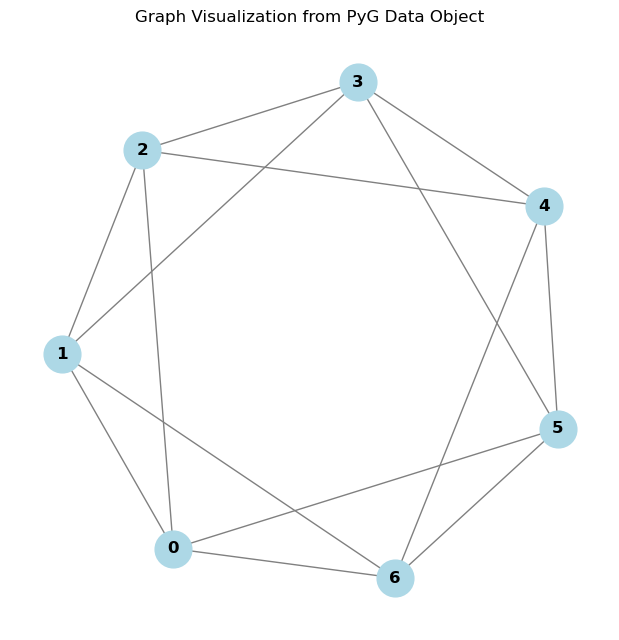

In [17]:
# ====================== SETUP ======================
num_nodes = 7
num_edges = 14
num_features = 4

# Node names for better readability
nodes = [f"Node_{i}" for i in range(num_nodes)]

# Edge index (undirected cycle-like graph)
edge_index = torch.tensor([
    [0, 0, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6],
    [1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 0, 0, 1]
], dtype=torch.long)

# Edge features (14 edges × 4 features)
edge_attr = torch.tensor([
    [0.1, 0.2, 0.3, 0.4],
    [0.5, 0.6, 0.7, 0.8],
    [0.9, 1.0, 1.1, 1.2],
    [1.3, 1.4, 1.5, 1.6],
    [1.7, 1.8, 1.9, 2.0],
    [2.1, 2.2, 2.3, 2.4],
    [2.5, 2.6, 2.7, 2.8],
    [2.9, 3.0, 3.1, 3.2],
    [3.3, 3.4, 3.5, 3.6],
    [3.7, 3.8, 3.9, 4.0],
    [4.1, 4.2, 4.3, 4.4],
    [4.5, 4.6, 4.7, 4.8],
    [4.9, 5.0, 5.1, 5.2],
    [5.3, 5.4, 5.5, 5.6]
], dtype=torch.float)

print(f"Edge feature tensor shape: {edge_attr.shape}")  # (num_edges, num_features)

data = Data(
    x=torch.randn(num_nodes, 8),           # dummy node features
    edge_index=edge_index,
    edge_attr=edge_attr
)

# Convert to NetworkX for visualization
G = to_networkx(data, edge_attrs=['edge_attr'], to_undirected=True)

# ====================== EDGE FEATURE ANALYSIS ======================

print("\n=== Edge Feature Tensor Analysis ===")
print(f"Min value : {edge_attr.min():.3f}")
print(f"Max value : {edge_attr.max():.3f}")
print(f"Mean      : {edge_attr.mean():.3f}")
print(f"Std       : {edge_attr.std():.3f}")

print(f"\nNode features shape: {data.x.shape}")
print(f"Node features:\n{data.x}")
print(f"\nEdge index shape: {data.edge_index.shape}")
print(f"Edge index:\n{data.edge_index}")
print(f"\nEdge attributes shape: {data.edge_attr.shape}")
print(f"Edge attributes:\n{data.edge_attr}")

# visualising
pos = nx.spring_layout(G)
plt.figure(figsize=(6,6))
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=700, font_weight='bold')
plt.title("Graph Visualization from PyG Data Object")
plt.axis('off')
plt.show()

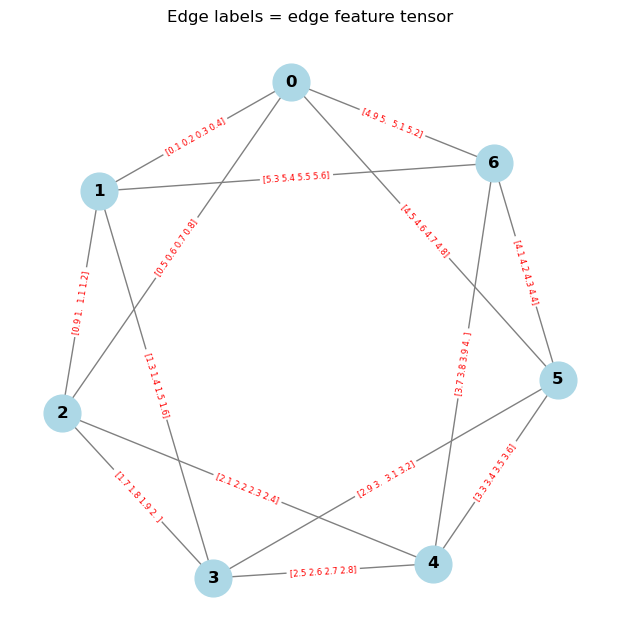

In [18]:
# visualise the feature tensor as edge labels
G = to_networkx(data, to_undirected=True)
pos = nx.spring_layout(G)
edge_labels = {
    (data.edge_index[0, i].item(), data.edge_index[1, i].item()): f"{data.edge_attr[i].numpy().round(2)}"
    for i in range(data.num_edges)
}
plt.figure(figsize=(6,6))
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=700, font_weight='bold')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6, font_color='red')
plt.title("Edge labels = edge feature tensor")
plt.axis('off')
plt.show()

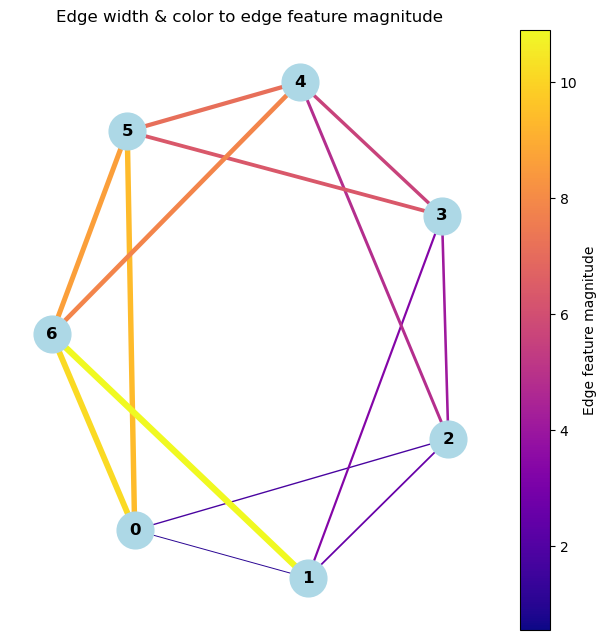

In [19]:
G = to_networkx(data, to_undirected=True, edge_attrs=['edge_attr'])
pos = nx.spring_layout(G)

# Aggregate edge features to scalar magnitude
edge_weights = np.array([
    np.linalg.norm(G[u][v]['edge_attr'])
    for u, v in G.edges()
])

# Map magnitude → width and color
edge_widths = 0.5 + (edge_weights / edge_weights.max()) * 4.0
edge_colors = plt.cm.plasma(edge_weights / edge_weights.max())

plt.figure(figsize=(6, 6))
nx.draw(G, pos,
        with_labels=True,
        node_color='lightblue',
        node_size=700,
        font_weight='bold',
        edge_color=edge_colors,
        width=edge_widths)

# Colorbar to read magnitude values
sm = plt.cm.ScalarMappable(cmap=plt.cm.plasma,
                            norm=plt.Normalize(edge_weights.min(), edge_weights.max()))
plt.colorbar(sm, label='Edge feature magnitude', ax=plt.gca())
plt.title("Edge width & color to edge feature magnitude")
plt.axis('off')
plt.show()


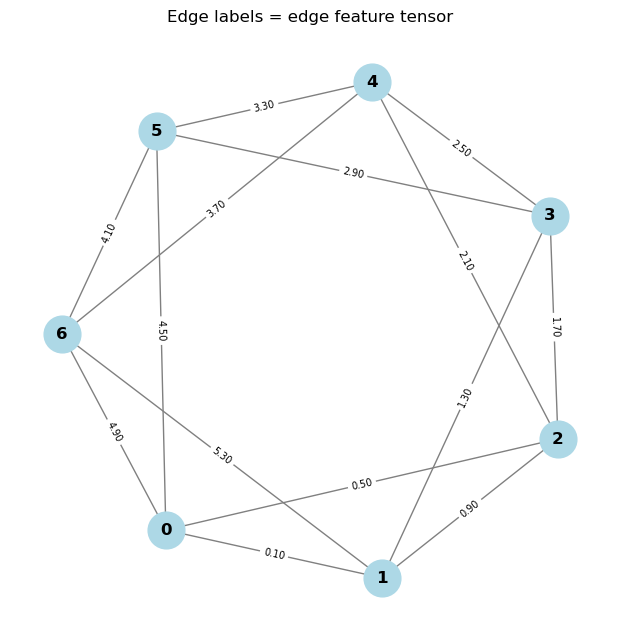

In [20]:
# visualise the feature tensor as edge labels
edge_labels = {(u, v): f"{G[u][v]['edge_attr'][0]:.2f}" for u, v in G.edges()}

plt.figure(figsize=(6,6))
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=700, font_weight='bold')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)
plt.title("Edge labels = edge feature tensor")
plt.axis('off')
plt.show()

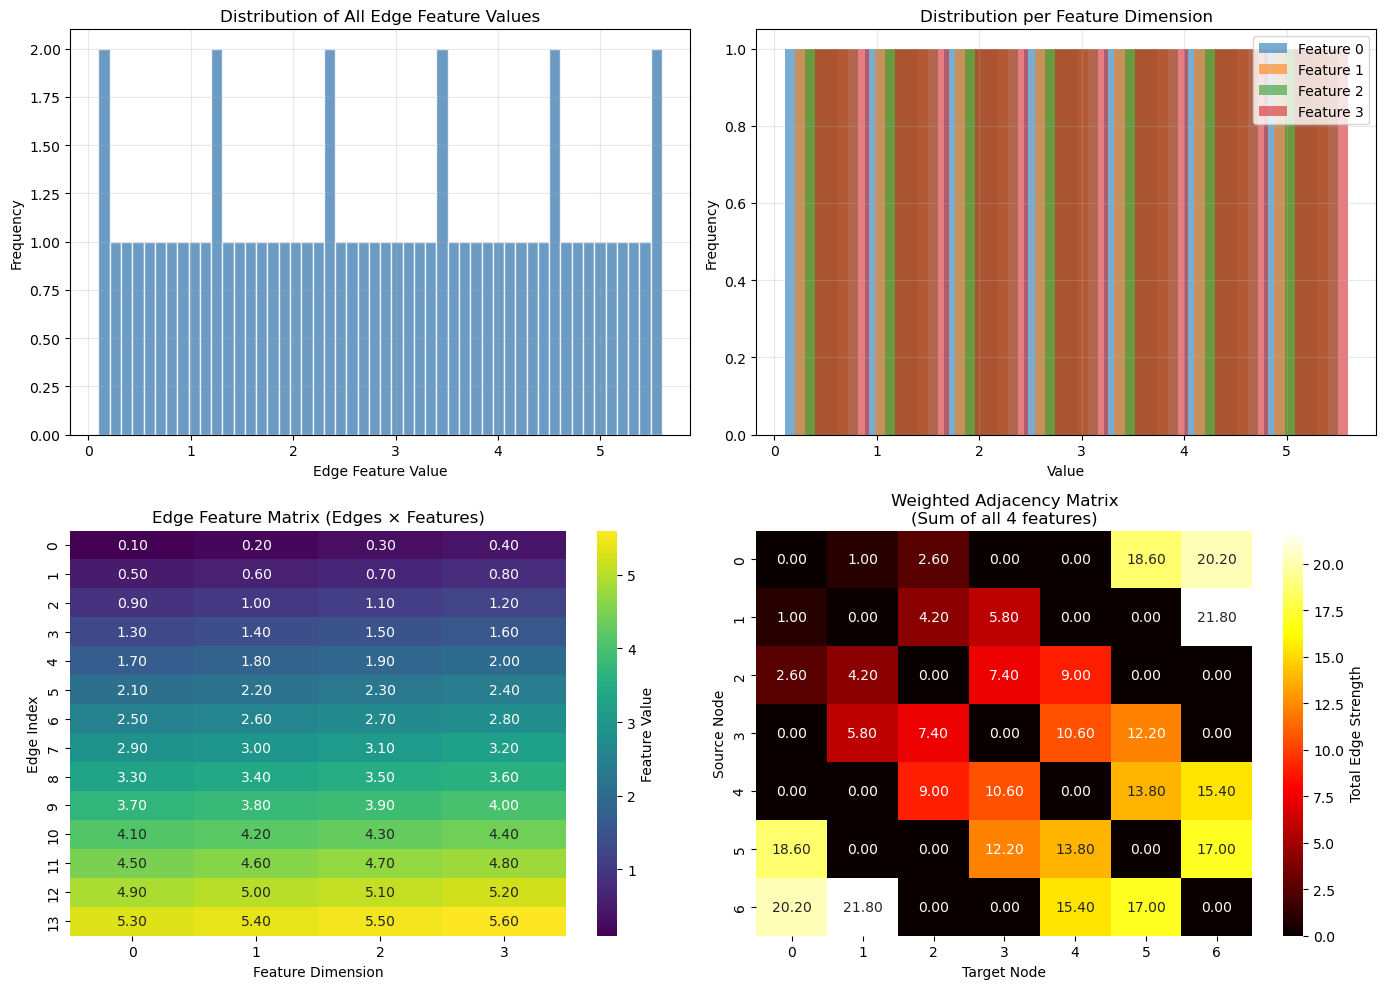

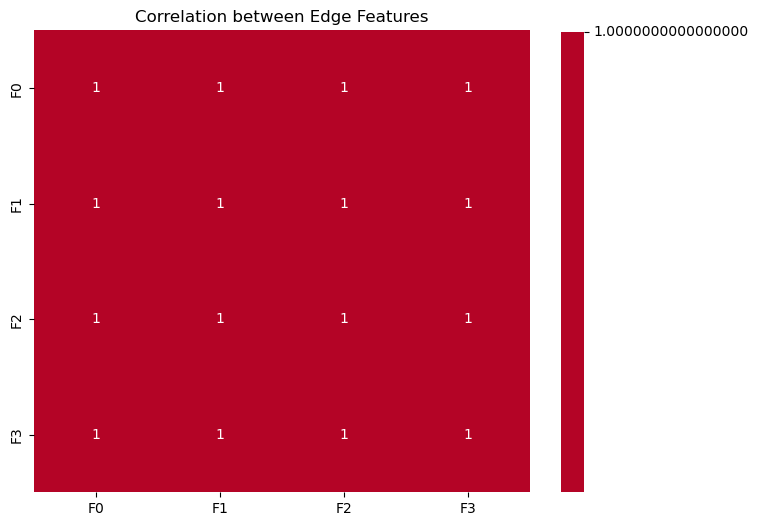


Per-feature statistics:
Feature 0:  mean=2.700, std=1.673, min=0.100, max=5.300
Feature 1:  mean=2.800, std=1.673, min=0.200, max=5.400
Feature 2:  mean=2.900, std=1.673, min=0.300, max=5.500
Feature 3:  mean=3.000, std=1.673, min=0.400, max=5.600


In [21]:
# 1. Distribution of all edge feature values
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
all_values = edge_attr.flatten().numpy()
plt.hist(all_values, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
plt.xlabel('Edge Feature Value')
plt.ylabel('Frequency')
plt.title('Distribution of All Edge Feature Values')
plt.grid(True, alpha=0.3)

# 2. Distribution per feature dimension
plt.subplot(2, 2, 2)
for i in range(num_features):
    plt.hist(edge_attr[:, i].numpy(), bins=20, alpha=0.6, label=f'Feature {i}')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Distribution per Feature Dimension')
plt.legend()
plt.grid(True, alpha=0.3)

# 3. Heatmap of edge features (edges × features)
plt.subplot(2, 2, 3)
sns.heatmap(edge_attr.numpy(), 
            annot=True, 
            fmt=".2f", 
            cmap='viridis',
            cbar_kws={'label': 'Feature Value'})
plt.xlabel('Feature Dimension')
plt.ylabel('Edge Index')
plt.title('Edge Feature Matrix (Edges × Features)')

# 4. Weighted Adjacency Matrix (sum of features or specific feature)
plt.subplot(2, 2, 4)
# Option A: Sum of all features as edge weight
edge_weights = edge_attr.sum(dim=1).numpy()

A = np.zeros((num_nodes, num_nodes))
for i, (src, dst) in enumerate(edge_index.t().numpy()):
    A[src, dst] = edge_weights[i]
    A[dst, src] = edge_weights[i]  # undirected

sns.heatmap(A, annot=True, fmt=".2f", cmap='hot', cbar_kws={'label': 'Total Edge Strength'})
plt.title('Weighted Adjacency Matrix\n(Sum of all 4 features)')
plt.xlabel('Target Node')
plt.ylabel('Source Node')

plt.tight_layout()
plt.show()

# ====================== ADDITIONAL USEFUL INSIGHTS ======================

# Feature correlation across edges
plt.figure(figsize=(8, 6))
corr = np.corrcoef(edge_attr.numpy().T)
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, 
            xticklabels=[f'F{i}' for i in range(num_features)],
            yticklabels=[f'F{i}' for i in range(num_features)])
plt.title('Correlation between Edge Features')
plt.show()

# Statistics per feature
print("\nPer-feature statistics:")
for i in range(num_features):
    feat = edge_attr[:, i]
    print(f"Feature {i}:  mean={feat.mean():.3f}, std={feat.std():.3f}, "
          f"min={feat.min():.3f}, max={feat.max():.3f}")

If you wish to study edge features more thoroughly, here are some to consider :
- individual feature pairwise scatter plots.
- Edge feature PCA / t-SNE projection.
- Comparison between different aggregation methods (mean, max, sum).

## Feature Normalisation 

Normalisation is a transformation applied to feature vectors to improve numerical stability and learning dynamics. The necessity of normalization arises from the fact that raw features often have arbitary scales, unites, or ranges. Consider a graph where one node feature is temperature in Kelvin and another is population count. Their magnitues differ by oders of magnitude. Without normalization, gradient-based optimization will be dominated by the feature with the larger scale, and the model's updates will become ill-conditioned. 

There are two distinct contexts for normalization in graph settings. The first is per-feature normalization across nodes. For a given feature dimension across all nodes, we compute the mean and standard deviation and standardize to zero mean and unit variance. This is identical to standard practice in tabular data. The second is per-node normalization across features, where we normalize the feature vector of each node to have unit norm. The latter is useful when the absolute magnitude of a node’s feature vector is irrelevant but the relative distribution across dimensions matters.

Edge features require separate consideration. They cannot be normalized using node statistics because the set of edges is of different cardinality and structure. The standard approach is per-edge-feature normalization across all edges. However, this breaks when edge features are heterogeneous. If one edge feature is discrete and another is continuous, or if missing values are present, global normalization becomes problematic. A more robust alternative is to apply a learned affine transformation per feature type, or to embed discrete edge features directly as learnable vectors without normalization.

The deeper theoretical point is this. Normalization changes the geometry of the feature space. Standardization imposes a Euclidean geometry where all dimensions contribute equally to distances. Per-node normalization projects features onto a hypersphere, inducing a cosine similarity geometry. The choice of normalization must match the inductive bias of the downstream algorithm. If you are using a graph neural network with sum aggregation, per-node normalization is often harmful because it discards degree-dependent magnitude information. If you are using attention mechanisms, per-node normalization may be beneficial because attention weights are naturally scale-invariant.

I will close with a practical warning. Many practitioners normalize features without asking whether the transformation preserves the semantics of the original measurement. If a node feature is a count, standardization destroys the interpretation that zero means absence. If an edge feature is a probability, per-edge normalization across the graph destroys the absolute confidence calibration. Normalization is not a free lunch. It is a deliberate modeling choice that should be documented and justified, not applied as a default preprocessing step. In my research group, we require that every normalized feature be accompanied by a written justification of why the original scale is not informative. That discipline alone has saved more hours of debugging than any automated pipeline.


# Graph properties & Metrics

In [81]:
# let's first build a solid graph for other purposes

nodes = np.array(range(0, 200, 1))
edge_list = np.random.randint(200, size=(600, 2))
weights = np.round(np.random.rand(600), decimals=3)
edge_attr = np.column_stack((edge_list, weights))

In [83]:
# now for actuall representation in memory, we can either use a weighted adjacency list (dict of dicts) or an adjacency matrix
# I'll go with the adjacency list for less memory usage

graph = {}
for src, dst, w in edge_attr:
    src, dst = int(src), int(dst)
    if src not in graph:
        graph[src] = {}
        graph[src][dst] = w

In [84]:
G = nx.DiGraph()
for src, dst, w in edge_attr:
    G.add_edge(int(src), int(dst), weight=w)

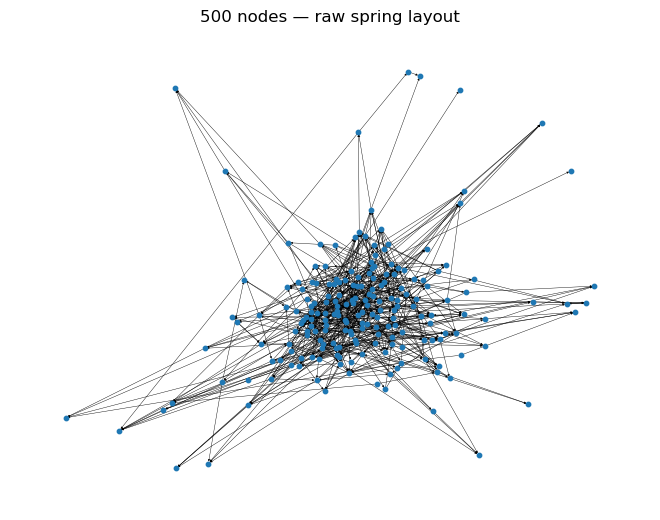

In [85]:
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, node_size=10, width=0.3, arrowsize=3)
plt.title("500 nodes — raw spring layout")
plt.show()

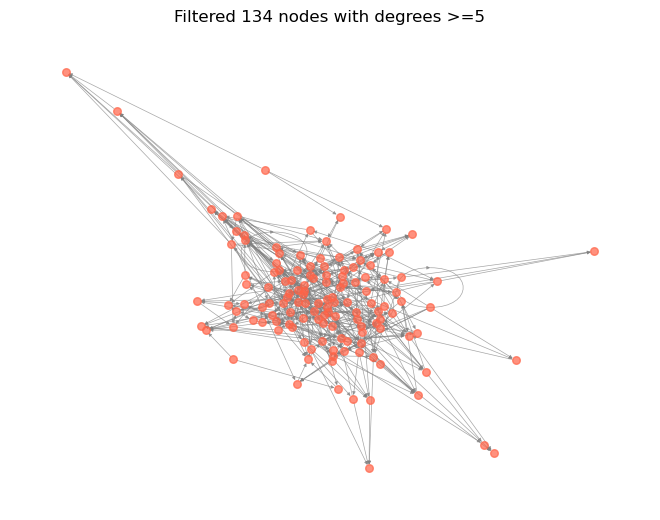

In [87]:
important = [n for n in G.nodes if G.degree(n) >=5]
subgraph = G.subgraph(important)
pos = nx.spring_layout(subgraph, seed=42)
nx.draw(subgraph, pos, node_size=30, width=0.5, arrowsize=5,node_color="tomato", edge_color="gray", alpha=0.7)
plt.title(f"Filtered {len(important)} nodes with degrees >=5")
plt.show()

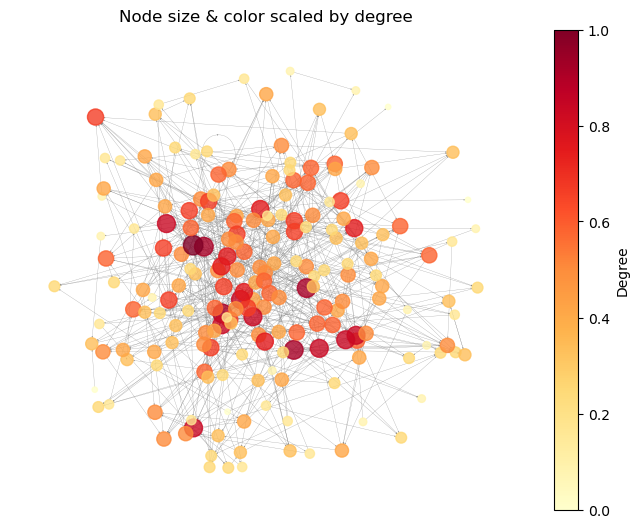

In [91]:
degrees = dict(G.degree())
node_list = list(G.nodes())
sizes  = [degrees[n] * 15 for n in node_list]       # scale node size
colors = [degrees[n] for n in node_list]             # map to colormap

pos = nx.spring_layout(G, seed=42, k=0.3, iterations=50)

nx.draw(
    G, pos,
    nodelist=node_list,
    node_size=sizes,
    node_color=colors,
    cmap=plt.cm.YlOrRd,        # low degree → yellow, high → red
    width=0.2,
    arrowsize=2,
    edge_color="gray",
    alpha=0.8,
)

plt.colorbar(plt.cm.ScalarMappable(cmap=plt.cm.YlOrRd), label="Degree", ax=plt.gca())
plt.title("Node size & color scaled by degree")
plt.show()


Graph has a decent set of properties and metrics which form the fundamental descriptive language of graph analysis. Each reveals a different structural dimension, and together they provide a profile that distinguishes a social network from a transportation grid from a protein interaction map.

Degree is the simplest but most informative local property. For an undirected graph, the degree of a node is the number of edges incident to it. For directed graphs, we separate in-degree, the number of incoming edges, from out-degree, the number of outgoing edges. The distinction is not merely technical. In a citation network, in-degree measures influence or recognition, while out-degree measures breadth of reference. In a web graph, pages with high in-degree are authoritative, while pages with high out-degree are hubs. The degree sequence of a graph, the list of degrees sorted, encodes fundamental constraints. The handshaking lemma states that the sum of all degrees equals twice the number of edges. For directed graphs, the sum of in-degrees equals the sum of out-degrees, both equal to the number of edges.

In [22]:

def undirected_degree(adj_list: dict, node) -> int:
    """Degree of a node in an undirected graph: number of incident edges."""
    return len(adj_list[node])


def in_degree(adj_list: dict, node) -> int:
    """In-degree: number of edges pointing INTO `node`.
    In a citation network this measures influence/recognition;
    on the web, high in-degree marks authoritative pages.
    """
    return sum(1 for src in adj_list if node in adj_list[src])


def out_degree(adj_list: dict, node) -> int:
    """Out-degree: number of edges leaving `node`.
    In a citation network this measures breadth of reference;
    on the web, high out-degree marks hub pages.
    """
    return len(adj_list[node])


def degree_sequence(adj_list: dict, directed: bool = False) -> list:
    """Sorted list of degrees — a fundamental graph invariant.
    For directed graphs, returns sorted (in_deg + out_deg) per node.
    """
    if directed:
        degs = [in_degree(adj_list, v) + out_degree(adj_list, v) for v in adj_list]
    else:
        degs = [undirected_degree(adj_list, v) for v in adj_list]
    return sorted(degs, reverse=True)


def verify_handshaking_lemma(adj_list: dict, num_edges: int) -> bool:
    """Handshaking lemma: sum of degrees == 2 * |E| for undirected graphs.
    Each edge contributes 1 to the degree of each of its two endpoints.
    """
    total = sum(undirected_degree(adj_list, v) for v in adj_list)
    return total == 2 * num_edges


def verify_directed_degree_identity(adj_list: dict, num_edges: int) -> bool:
    """For directed graphs: sum(in_deg) == sum(out_deg) == |E|.
    Every edge has exactly one tail and one head.
    """
    total_in  = sum(in_degree(adj_list, v)  for v in adj_list)
    total_out = sum(out_degree(adj_list, v) for v in adj_list)
    return total_in == total_out == num_edges


# --- Matrix-based variants (useful when you already have A) ---

def degrees_from_adjacency(A: np.ndarray, directed: bool = False):
    """Compute degrees directly from an adjacency matrix.
    Undirected: degree = row sum (== column sum, since A is symmetric).
    Directed:   out_degree = row sum, in_degree = column sum.
    """
    if not directed:
        return A.sum(axis=1)           # shape (N,)
    out_deg = A.sum(axis=1)
    in_deg  = A.sum(axis=0)
    return in_deg, out_deg


def degree_distribution(adj_list: dict) -> dict:
    """P(k): fraction of nodes with degree k. Basis for power-law analysis."""
    degs = [undirected_degree(adj_list, v) for v in adj_list]
    n = len(degs)
    return {k: c / n for k, c in Counter(degs).items()}


In [30]:
G = {0:[1,2],1:[0,2],2:[0,1,2]}
for i in G.keys():
    print(f"Undirected degree for node {i} : {undirected_degree(G, i)} degrees")

Undirected degree for node 0 : 2 degrees
Undirected degree for node 1 : 2 degrees
Undirected degree for node 2 : 3 degrees


In-degree for node 0 : 2
Out-degree for node 0 : 2
In-degree for node 1 : 2
Out-degree for node 1 : 1
In-degree for node 2 : 2
Out-degree for node 2 : 3


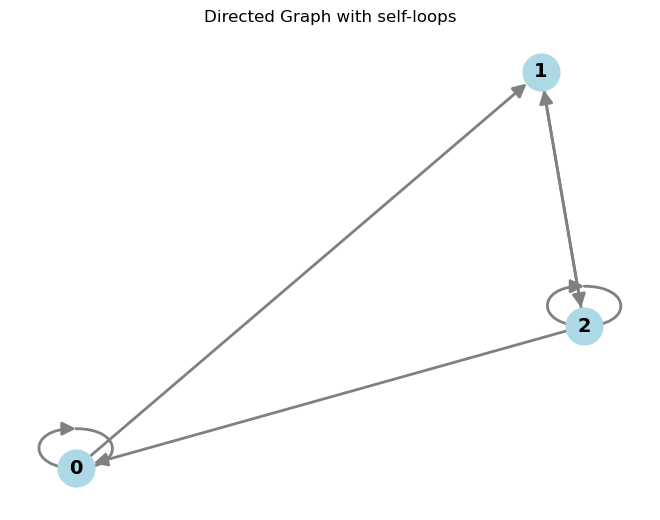

In [40]:
adjacency_list={0:[0,1],1:[2],2:[0,1,2]}
for i in adjacency_list.keys():
    print(f"In-degree for node {i} : {in_degree(adjacency_list, i)}")
    print(f"Out-degree for node {i} : {out_degree(adjacency_list, i)}")

G = nx.DiGraph()
for node, neighbors in adjacency_list.items():
    for neighbor in neighbors:
        G.add_edge(node, neighbor)
    
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color="lightblue", node_size=700, font_size=14, font_weight="bold", arrowsize=20, edge_color="gray", width=2)

plt.title("Directed Graph with self-loops")
plt.show()

In [2]:
# Undirected triangle: 0-1, 1-2, 2-0
G = {0: [1, 2], 1: [0, 2], 2: [0, 1]}
assert degree_sequence(G) == [2, 2, 2]
assert verify_handshaking_lemma(G, num_edges=3)

# Directed: 0->1, 1->2, 0->2
D = {0: [1, 2], 1: [2], 2: []}
assert in_degree(D, 2) == 2 and out_degree(D, 0) == 2
assert verify_directed_degree_identity(D, num_edges=3)

## Density

Density moves from node-level to graph-level aggregation. It is the ratio of actual edges to the maximum possible edges. For an undirected graph with n nodes, maximum edges is n(n-1)/2. For a directed graph, it is n(n-1). Density lies between zero and one. A complete graph has density one. Most real-world graphs are sparse, meaning density tends to zero as n grows. The importance of density is comparative. Two graphs of the same size can be compared by their densities, but density alone does not distinguish a graph with many isolated nodes from a graph that is nearly complete except for a few missing edges. That distinction requires connectivity measures.

## Connectivity

Connectivity, specifically the decomposition into connected components, addresses exactly that. A connected component is a maximal set of nodes where any two nodes are reachable via some path. For directed graphs, we distinguish weakly connected components, where direction is ignored, from strongly connected components, where directed paths must exist in both directions between any two nodes in the component. The component structure reveals modularity and fragmentation. A social network with many small components suggests communities that do not interact. A single giant component with many small satellite components is typical of web graphs and citation networks. The size distribution of components follows characteristic patterns under random graph models and deviates from those patterns in meaningful ways for real data.

# Paths in Graphs

A path is a sequence of nodes where consecutive nodes are adjacent. Paths are the atomic units of connectivity. The length of a path is the number of edges traversed. Shortest paths, also called geodesics, minimize this length between a source and target. Computing all-pairs shortest paths is computationally expensive, O(n^3) with the Floyd-Warshall algorithm, but for sparse graphs, Johnson's algorithm or repeated Dijkstra from each source improves to O(n^2 log n + n m). The importance of shortest paths lies not only in navigation but in centrality measures. Betweenness centrality counts how many shortest paths pass through a node. Closeness centrality inverts the average shortest path distance to all other nodes.

## Diameter

Diameter is the maximum over all pairs of nodes of the shortest path distance. It answers the question: what is the longest geodesic in the graph? For a tree, the diameter can be found by two breadth-first searches. For general graphs, exact computation requires all-pairs shortest paths and is expensive. In practice, approximations using multiple random sources suffice for large graphs. The diameter of real networks is often surprisingly small. The famous small-world phenomenon, six degrees of separation, is precisely the observation that social network diameters grow logarithmically with n rather than linearly. A diameter that grows slowly indicates high connectivity and efficient information propagation. A diameter that grows rapidly or is infinite due to disconnected components indicates fragmentation

## Clustering coefficient

The clustering coefficient measures the extent to which neighbors of a node are also neighbors of each other. For an undirected graph, the local clustering coefficient of a node with degree k is the number of edges among its neighbors divided by k(k-1)/2, the maximum possible. The global clustering coefficient is either the average of local coefficients or the ratio of closed triples to all triples in the graph. High clustering indicates transitivity. In social networks, if Alice is friends with Bob and Bob is friends with Carol, the probability that Alice and Carol are friends is high. This is not true in random graphs. The clustering coefficient captures this deviation from randomness. A graph with high clustering and small diameter is precisely the definition of a small-world network, as formalized by Watts and Strogatz.

---

These metrics are not independent. A graph with high density necessarily has high clustering and small diameter, but the converse does not hold. Sparse graphs can exhibit high clustering and small diameter simultaneously, as seen in many biological and social networks. Understanding the joint distribution of these metrics across a graph family is more informative than any single number. When I evaluate a graph generative model, I do not ask whether it matches the degree distribution alone. I ask whether it simultaneously reproduces the degree distribution, the clustering coefficient, the diameter, and the component size distribution. A model that matches all four is likely capturing the true underlying structure. A model that matches only one or two is merely fitting noise.

---

# Types of Graphs (with examples)

- Trees
- DAGs (Directed Acyclic Graphs)
- Bipartite graphs
- Heterogeneous graphs
- Dynamic graphs

# Classic Graph Algorithms

- BFS and DFS (traversal)
- Dijkstra (shortest path)
- PageRank (Node importance)
- Connected components

# Graph as a Matrix : The Linear Algebra View
- Adjacency Matrix A
- Degree matrix D
- Laplacien L = D-A
- why the Laplacien matters (leads directly into spectral GNNs)

# Practical: Building Graphs from real data

- Building a graph from an image
- From a CSV/tabular dataset
- from a molecule (RDKit)
- From a social network

## Building a Graph from an Image

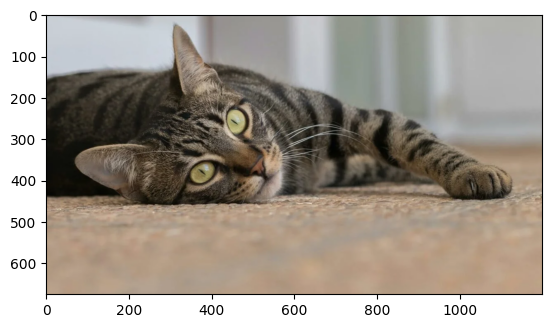

In [2]:
# task 1 : Represent an image as a graph
image = cv2.imread('../misc/cat.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image)

In [3]:
print("Type of image variable:", type(image))
print("Shape of image variable:", image.shape)
print("Data type of image variable:", image.dtype)
print("image : \n", image)

Type of image variable: <class 'numpy.ndarray'>
Shape of image variable: (675, 1200, 3)
Data type of image variable: uint8
image : 
 [[[199 205 210]
  [199 205 210]
  [199 205 210]
  ...
  [179 180 175]
  [179 180 175]
  [179 180 175]]

 [[199 205 210]
  [199 205 210]
  [199 205 210]
  ...
  [179 180 175]
  [179 180 175]
  [179 180 175]]

 [[200 206 211]
  [200 206 211]
  [200 206 211]
  ...
  [179 180 175]
  [179 180 175]
  [179 180 175]]

 ...

 [[188 165 141]
  [188 165 141]
  [188 165 141]
  ...
  [188 159 137]
  [188 159 137]
  [188 159 137]]

 [[188 165 141]
  [188 165 141]
  [188 165 141]
  ...
  [188 159 137]
  [188 159 137]
  [188 159 137]]

 [[188 165 141]
  [188 165 141]
  [188 165 141]
  ...
  [188 159 137]
  [188 159 137]
  [188 159 137]]]


Now how de we actually move from a 2D array to a graph structure ? We could consider each pixel as a node and then connect the nodes based on their spatial proximity. For example, we could connect each pixel to its 8 neighboring pixels (the ones that are directly adjacent to it). This way, we can create a graph where each node represents a pixel and the edges represent the connections between neighboring pixels.
We can also assign features to each node (pixel) based on its color values (RGB) and possibly other attributes like intensity or texture. This way, we can use the graph structure to perform various tasks such as image segmentation, object recognition, or even image generation using Graph Neural Networks (GNNs).
To summarize, representing an image as a graph involves treating each pixel as a node and connecting them based on their spatial relationships, while also assigning features to the nodes to capture the information contained in the image.

In [18]:
# reshape the (H,W,3) array into a (H*W,3) array
if image is None:
    raise ValueError("Image not found. Please check the file path.")
H, W, C = image.shape
image_reshaped = image.reshape(-1, C) # node feature matrix
image_reshaped = image_reshaped / 255.0 #normalize to (0,1)
print("Reshaped image shape:", image_reshaped.shape)
# The core operation is img.reshape(-1, 3). The -1 tells NumPy to infer that dimension automatically -- it computes H×W for you. The result is your node feature matrix X where row n corresponds to the pixel at (i, j) via n = i*W + j. The three columns are the raw R, G, B values.

Reshaped image shape: (810000, 3)


In [36]:
# building the edge index 
#for every pixel, find its valid neighbors, record the directed pair (src,dst) and stack all pairs into a (2, num_edges) tensor
# Corner pixels end up with 3 neighbors, edge pixels with 5, and interior pixels with the full 8
# the edges are directed, meaning A->B and B->A are considered different edges. This is important for many GNN architectures that treat incoming and outgoing edges differently.
# the final edge_index shape is (2,E) where E grows with image size roughly as 8*H*W for large images (since most pixels have 8 neighbors). For a 100x100 image, you might have around 80,000 edges. We typically wan to keep edge_index as torch.long tensor on the same device as your node features for efficient processing in GNNs.

offsets = [(-1, -1), (-1, 0), (-1, 1),
           (0, -1),           (0, 1),
           (1, -1),  (1, 0),  (1, 1)]

sources = []
destinations = []
for i in range(H):
    for j in range(W):
        node_index = i * W + j
        for di, dj in offsets:
            ni, nj = i + di, j + dj
            if 0 <= ni < H and 0 <= nj < W: #boundary check
                neighbor_node_index = ni * W + nj
                sources.append(node_index)
                destinations.append(neighbor_node_index)

# edge_index = np.stack([np.array(sources, dtype=np.int64),
#                        np.array(destinations, dtype=np.int64)], axis=0)

edge_index = torch.tensor([sources, destinations], dtype=torch.long)
X = torch.tensor(image_reshaped, dtype=torch.float32)

In [37]:
print("Edge index shape:", edge_index.shape)
print(edge_index)

Edge index shape: torch.Size([2, 6468754])
tensor([[     0,      0,      0,  ..., 809999, 809999, 809999],
        [     1,   1200,   1201,  ..., 808798, 808799, 809998]])


In [44]:
u, v = edge_index
diff = X[u] - X[v]
dist = diff.norm(dim=1)
edge_attr = dist.unsqueeze(1) # shape (E,1)
print(" edge attributes shape:", edge_attr.shape)
# The raw L2 distance in RGB sapce ranges from 0 to sqrt(3) * 255 ~ 441.67. Most GNN layers expect inputs in a bounded range. Normalizing to (0,1) can help stabilize training and make the edge attributes more comparable across different images. `dist = dist / (255.0 * 3**0.5)`
# 

 edge attributes shape: torch.Size([6468754, 1])


In [45]:
# using torch_geometric's Data class to represent the graph
data = Data(
    x = X, # node feature matrix (H*W, 3)
    edge_index = edge_index, # Graph topology (2, E)
    edge_attr = edge_attr, # Optional edge features, one row per edge
    y = None # Optional label; cab be a saclar (graph classification) or a vector per node
)

In [58]:
# validate edge_attr values
print("Min edge attribute value:", edge_attr.min())
print("Max edge attribute value:", edge_attr.max())
print("mean edge attribute value:", edge_attr.mean())
print("edge_attr sample values:", edge_attr[:10])

Min edge attribute value: tensor(0.)
Max edge attribute value: tensor(1.0461)
mean edge attribute value: tensor(0.0222)
edge_attr sample values: tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]])


In [59]:
print(data.validate(raise_on_error=True))
print(data.is_undirected()) # should return False since we created directed edges
print(data.num_nodes)
print(data.num_edges)

True
True
810000
6468754


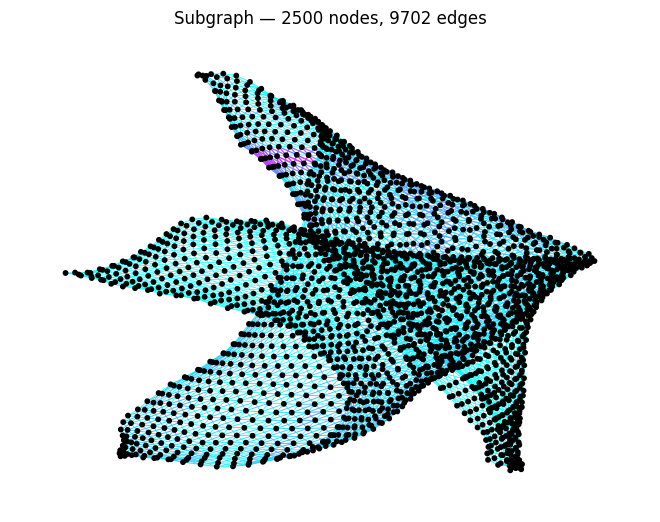

In [64]:
# --- Extract a small spatial patch ---
PATCH_ROW, PATCH_COL = 100, 100
PATCH_SIZE = 50  # 50x50 = 2500 nodes

patch_nodes = [
    (PATCH_ROW + i) * W + (PATCH_COL + j)
    for i in range(PATCH_SIZE)
    for j in range(PATCH_SIZE)
]

# --- Build a subgraph Data object ---
patch_nodes_tensor = torch.tensor(patch_nodes, dtype=torch.long)

sub_edge_index, sub_edge_attr = subgraph(   # <-- unpack attr directly, no mask
    patch_nodes_tensor,
    data.edge_index,
    edge_attr=data.edge_attr,
    relabel_nodes=True,
)
sub_x = data.x[patch_nodes_tensor]
sub_data = Data(x=sub_x, edge_index=sub_edge_index, edge_attr=sub_edge_attr)

G = to_networkx(sub_data, to_undirected=True, edge_attrs=['edge_attr'])

# Read weights in the exact order G.edges() returns them — avoids count mismatch
edge_weights = np.array([G[u][v]['edge_attr'][0] for u, v in G.edges()])
edge_widths = 0.5 + edge_weights * 3.0
edge_colors = plt.cm.cool(edge_weights / edge_weights.max())

node_colors = sub_x.numpy() / 255.0

nx.draw(G,
        node_color=node_colors,
        with_labels=False,
        node_size=10,
        edge_color=edge_colors,
        width=edge_widths)
plt.title(f"Subgraph — {sub_data.num_nodes} nodes, {sub_data.num_edges // 2} edges")
plt.show()


# Custom Graph Implementation/Class

In [66]:
# implementation of Graph class

class Graph:
    """
    A clean, flexible, and efficient Graph data structure for PyTorch Geometric-style graphs.
    Supports both CPU and GPU tensors.
    """
    
    def __init__(self,x: torch.Tensor,edge_index: torch.Tensor,edge_attr: Optional[torch.Tensor] = None,y: Optional[torch.Tensor] = None,num_nodes: Optional[int] = None,**kwargs: Any
):
        """
        Args:
            x: Node feature matrix of shape [num_nodes, num_node_features]
            edge_index: Edge index tensor of shape [2, num_edges] (COO format)
            edge_attr: Edge feature matrix of shape [num_edges, num_edge_features] (optional)
            y: Graph-level or node-level target labels (optional)
            num_nodes: Number of nodes (inferred from x or edge_index if not provided)
            **kwargs: Additional graph attributes (e.g. pos, batch, etc.)
        """
        # Validation
        if not isinstance(x, torch.Tensor):
            x = torch.tensor(x, dtype=torch.float32)
        if not isinstance(edge_index, torch.Tensor):
            edge_index = torch.tensor(edge_index, dtype=torch.long)
        
        if edge_index.dim() != 2 or edge_index.size(0) != 2:
            raise ValueError("edge_index must be a tensor of shape [2, num_edges]")
        
        # Store core attributes
        self.x = x
        self.edge_index = edge_index
        self.edge_attr = edge_attr
        self.y = y
        self.num_nodes = num_nodes or x.size(0)
        
        # Store any additional attributes
        for key, value in kwargs.items():
            setattr(self, key, value)
    
    @property
    def num_edges(self) -> int:
        """Number of edges in the graph."""
        return self.edge_index.size(1)
    
    @property
    def num_node_features(self) -> int:
        """Number of features per node."""
        return self.x.size(1) if self.x.dim() > 1 else 1
    
    @property
    def num_edge_features(self) -> int:
        """Number of features per edge."""
        if self.edge_attr is None:
            return 0
        return self.edge_attr.size(1) if self.edge_attr.dim() > 1 else 1
    
    def is_directed(self) -> bool:
        """Check if the graph is directed."""
        row, col = self.edge_index
        # Check if for every edge (u, v), the reverse edge (v, u) also exists
        reverse_edges = torch.stack([col, row], dim=0)
        # Create a set of edge tuples for comparison
        edge_set = set(map(tuple, self.edge_index.t().tolist()))
        reverse_set = set(map(tuple, reverse_edges.t().tolist()))
        return not reverse_set.issubset(edge_set)
    
    def to(self, device: Union[str, torch.device]) -> 'Graph':
        """Move all tensors to the specified device (cpu/cuda)."""
        for key in self.__dict__:
            value = getattr(self, key)
            if isinstance(value, torch.Tensor):
                setattr(self, key, value.to(device))
        return self
    
    def cpu(self) -> 'Graph':
        return self.to('cpu')
    
    def cuda(self) -> 'Graph':
        return self.to('cuda')
    
    def __repr__(self) -> str:
        return (f"Graph(num_nodes={self.num_nodes}, "
                f"num_edges={self.num_edges}, "
                f"num_node_features={self.num_node_features}, "
                f"num_edge_features={self.num_edge_features})")    

In [ ]:
# visualise the custom graph class using pyvis
from pyvis.network import Network

# --- Config ---
PATCH_ROW, PATCH_COL = 100, 100   # top-left corner of the patch
PATCH_SIZE = 20                    # 20x20 = 400 nodes, manageable for pyvis

# --- Extract patch nodes (spatially connected) ---
patch_nodes = [
    (PATCH_ROW + i) * W + (PATCH_COL + j)
    for i in range(PATCH_SIZE)
    for j in range(PATCH_SIZE)
]
subgraph_nx = graph_nx.subgraph(patch_nodes)


# Make a mutable copy and strip non-serializable attributes
subgraph_nx = graph_nx.subgraph(patch_nodes).copy()
for node_id in subgraph_nx.nodes():
    subgraph_nx.nodes[node_id].pop('feature', None)

# Assign RGB color to each node
for node_id in subgraph_nx.nodes():
    r, g, b = image_reshaped[node_id]
    subgraph_nx.nodes[node_id]['color'] = f'rgb({r},{g},{b})'
    subgraph_nx.nodes[node_id]['size'] = 5
    subgraph_nx.nodes[node_id]['label'] = ''


# --- Build pyvis network ---
net = Network(height='750px', width='100%', directed=False, notebook=True)
net.from_nx(subgraph_nx)
net.show_buttons(filter_=['physics'])
net.show('graph_visualization.html')

print(f"Subgraph: {subgraph_nx.number_of_nodes()} nodes, {subgraph_nx.number_of_edges()} edges")

graph_visualization.html
Subgraph: 400 nodes, 1482 edges
